In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from textwrap import fill
import numpy as np
import pandas as pd
import scanpy.external as sce
import scanpy as sc
import anndata as an
from scipy.spatial.distance import cdist
import scvelo as scv
import gget
import re
import rapids_singlecell as rsc
from scipy.stats import linregress
from sklearn.preprocessing import MinMaxScaler
# import cellrank as cr

sc.settings.verbosity = 3 

print(scv.__version__)

0.3.3


In [2]:
import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger('py.warnings').setLevel(logging.ERROR)

# Load expression

In [3]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/pseudotime.h5ad"
adata = sc.read_h5ad(fpath)
adata.X = adata.layers['log_norm'].copy()
adata

CPU times: user 463 ms, sys: 2.1 s, total: 2.56 s
Wall time: 5.05 s


AnnData object with n_obs × n_vars = 15867 × 21412
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters', 'cluster_str', 'barcoded_phase', 'S_score', 'G2M_score', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'G1_pseudotime', 'G1_order', 'G2M_pseudotime', 'G2M_order', 'mean_pseudotime', 'mean_order', 'nnz'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersio

In [4]:
print(f"{len(adata.obs_names)=}")
print(f"{adata.obs_names.nunique()=}")

len(adata.obs_names)=15867
adata.obs_names.nunique()=15867


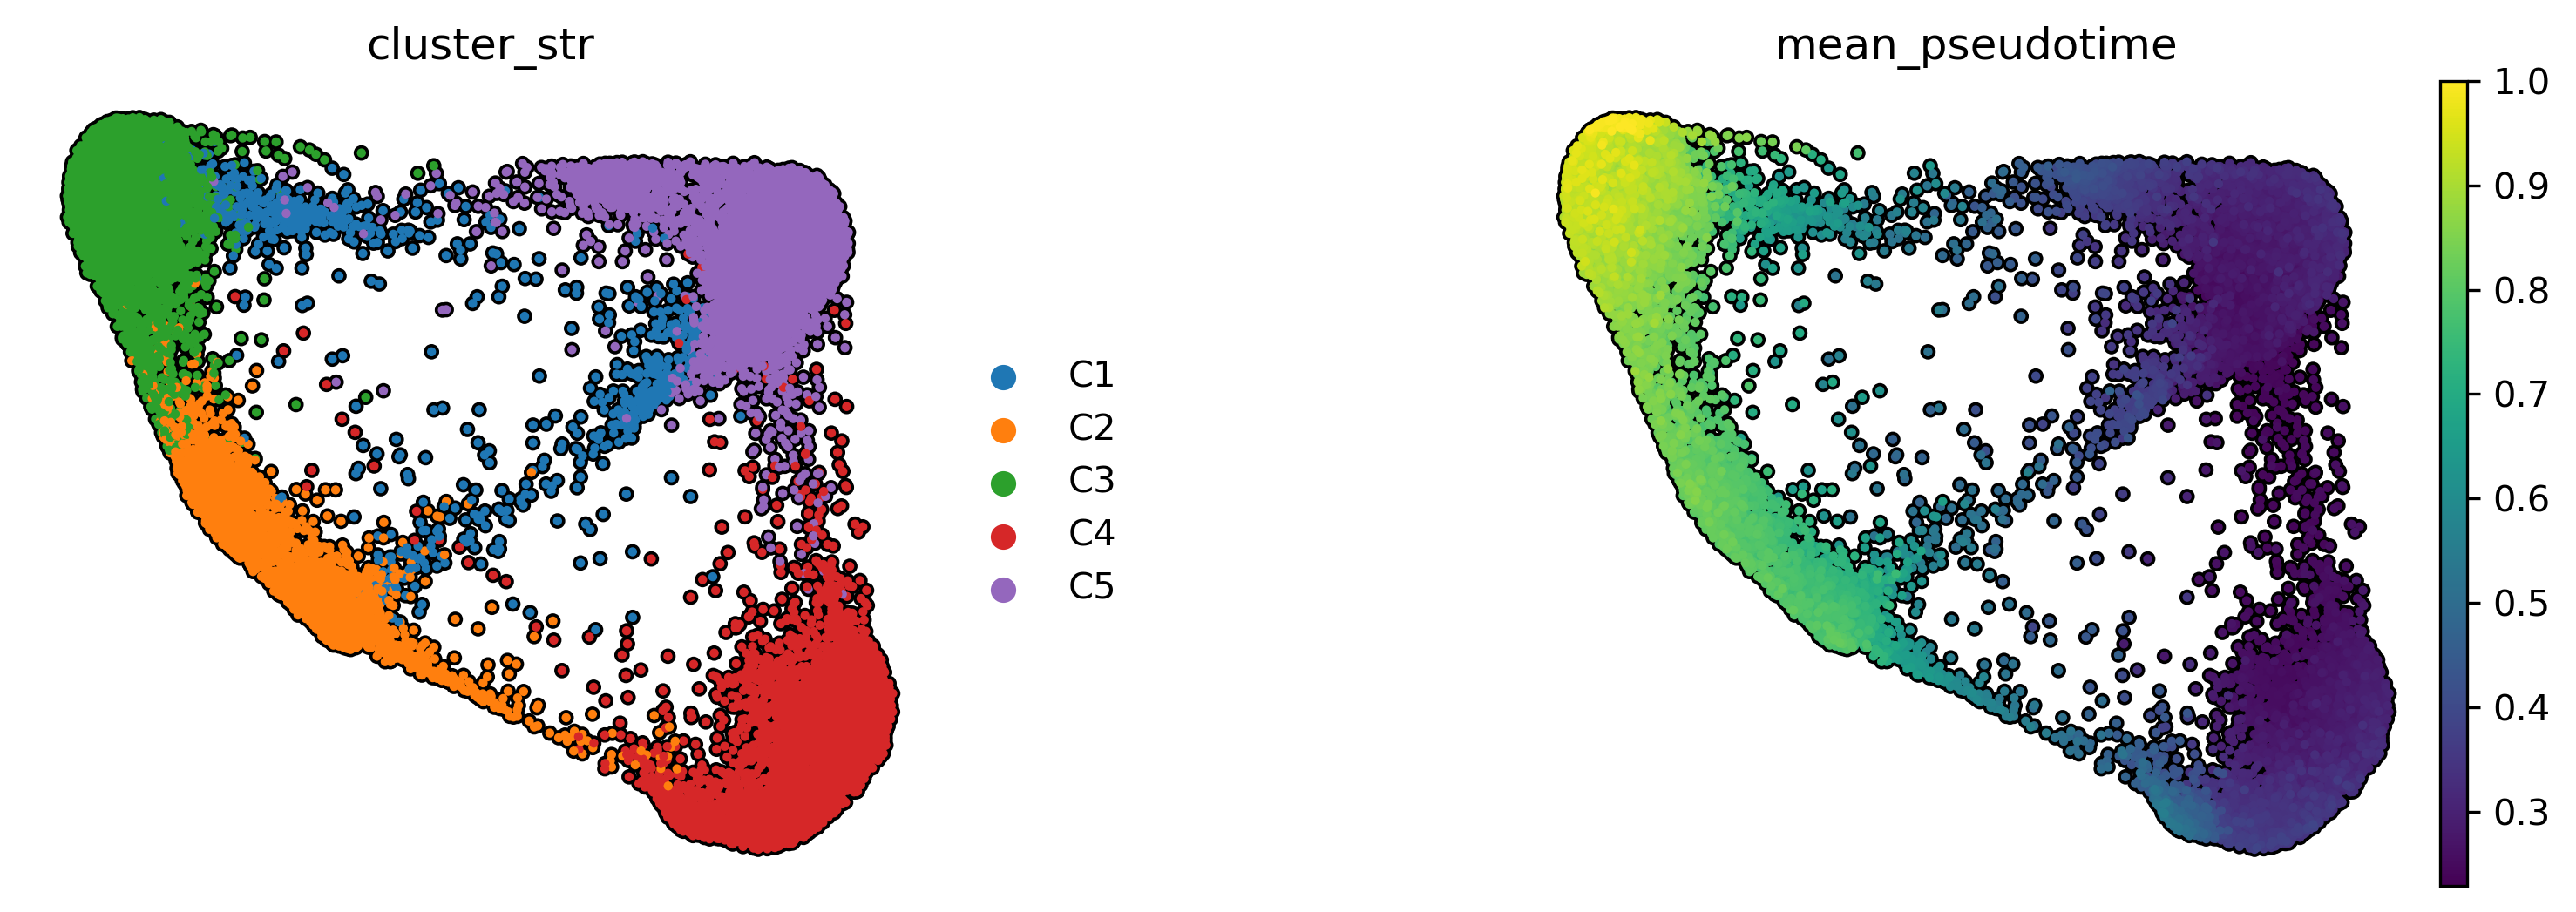

In [5]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    adata, 
    color=['cluster_str', 'mean_pseudotime'],
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

In [6]:
# break

# Load Velocity

In [7]:
%%time

fpaths = {
    "hsc" : "/scratch/indikar_root/indikar1/shared_data/hsc_velocyto/merged_NKUVW.loom",
    "fib" : "/scratch/indikar_root/indikar1/shared_data/fib_velocyto/merged_PW6SH.loom",
}

ldatas = []
for key, fpath in fpaths.items():
    print(f"Working {key}...")

    ldata = sc.read_loom(fpath)
    ldata.var_names_make_unique()

    # set the cell-ids back to barcodes
    ldata.obs['velocyto_cell_id'] = ldata.obs_names.copy()
    ldata.obs['cell_id'] = ldata.obs['velocyto_cell_id'].apply(lambda x: x.split(":")[1][:-1] + "-1")
    ldata.obs_names = ldata.obs['cell_id'].values

    # Print initial cell counts
    print(f"\tInitial cell count in ldata: {ldata.shape[0]}")
    print(f"\tInitial cell count in adata: {adata.shape[0]}")
    
    # IDs not retained in ldata
    removed_from_ldata = ldata.obs.index[~ldata.obs.index.isin(adata.obs_names)].tolist()
    
    # IDs not retained in adata
    removed_from_adata = adata.obs.index[~adata.obs.index.isin(ldata.obs_names)].tolist()
    
    # Filter ldata to keep only cells present in adata
    initial_ldata_count = ldata.shape[0]
    ldata = ldata[ldata.obs.index.isin(adata.obs_names), :].copy()
    print(f"\tFiltered ldata: {ldata.shape[0]} cells kept, {initial_ldata_count - ldata.shape[0]} cells removed")

    ldatas.append(ldata)

    
ldata = an.concat(ldatas)   
ldata

Working hsc...
	Initial cell count in ldata: 11933
	Initial cell count in adata: 15867
	Filtered ldata: 8326 cells kept, 3607 cells removed
Working fib...
	Initial cell count in ldata: 8963
	Initial cell count in adata: 15867
	Filtered ldata: 7541 cells kept, 1422 cells removed
CPU times: user 1min 3s, sys: 18.9 s, total: 1min 22s
Wall time: 1min 23s


AnnData object with n_obs × n_vars = 15867 × 38606
    obs: 'velocyto_cell_id', 'cell_id'
    layers: 'matrix', 'ambiguous', 'spliced', 'unspliced'

# Merge and Filter

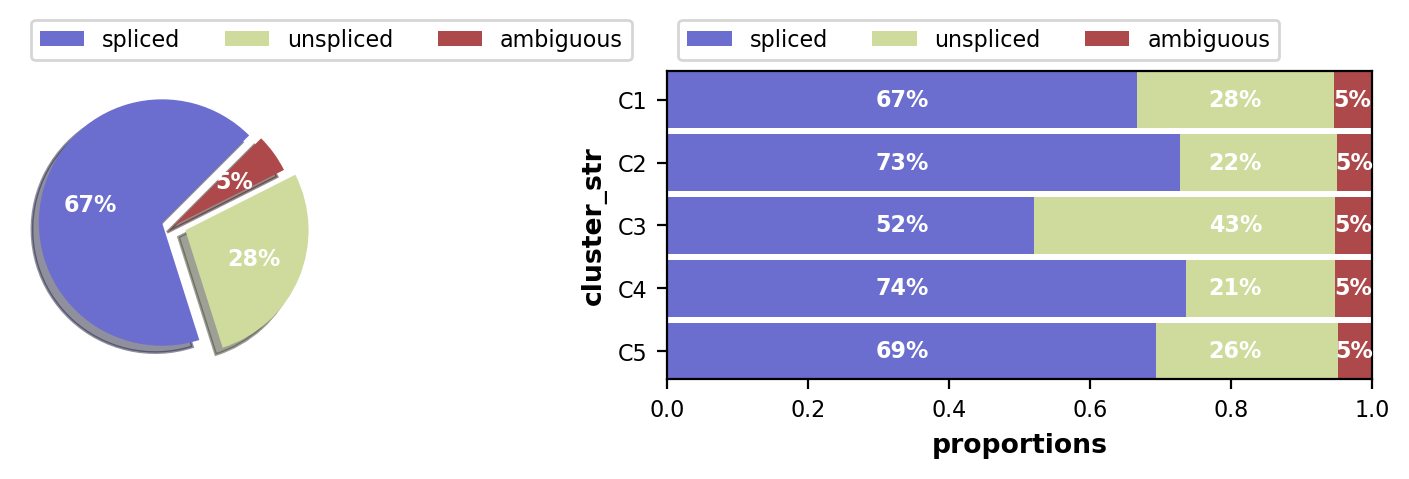

AnnData object with n_obs × n_vars = 15867 × 21412
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters', 'cluster_str', 'barcoded_phase', 'S_score', 'G2M_score', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'G1_pseudotime', 'G1_order', 'G2M_pseudotime', 'G2M_order', 'mean_pseudotime', 'mean_order', 'nnz', 'velocyto_cell_id', 'cell_id', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total

In [8]:
adata = scv.utils.merge(adata, ldata)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 7, 5

scv.pl.proportions(adata, groupby='cluster_str', dpi=200)

adata

# RNA Velocity

In [9]:
%%time
rsc.pp.neighbors(adata, n_neighbors=150, use_rep='X_pca_harmony')
scv.pp.moments(adata, use_rep='X_pca_harmony')

[2025-05-22 12:34:49.414] [CUML] [debug] n_neighbors=150
[2025-05-22 12:34:49.414] [CUML] [debug] Calling knn graph run
[2025-05-22 12:34:49.414] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-05-22 12:34:49.433] [CUML] [debug] Done. Calling remove zeros
Normalized count data: spliced, unspliced.
computing moments based on connectivities
    finished (0:00:31) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
CPU times: user 28.7 s, sys: 3.46 s, total: 32.1 s
Wall time: 32.2 s


In [17]:
%%time
outpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/DeepCycle/deepcycle_input.h5ad"

adata.write(outpath)
adata

CPU times: user 1.04 s, sys: 4.21 s, total: 5.25 s
Wall time: 15.7 s


AnnData object with n_obs × n_vars = 15867 × 21412
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters', 'cluster_str', 'barcoded_phase', 'S_score', 'G2M_score', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'G1_pseudotime', 'G1_order', 'G2M_pseudotime', 'G2M_order', 'mean_pseudotime', 'mean_order', 'nnz', 'velocyto_cell_id', 'cell_id', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total

In [10]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)